# Objective

    The objective of this project is to analyze smartphone usage behavior and identify patterns associated with smartphone addiction. This analysis explores the relationship between screen time, social media usage, sleep habits, stress levels, and productivity impacts among users. Through exploratory data analysis (EDA), the project aims to uncover meaningful behavioral insights and understand how excessive smartphone usage affects daily life. The study also compares addicted and non-addicted users to identify key contributing factors to smartphone dependency. The findings from this analysis can help promote digital wellness awareness and responsible smartphone usage habits.

### Import necessary libralies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import dataset

In [2]:
data=pd.read_csv("smartphone_uses.csv")

### Understand data

In [3]:
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
data.columns.tolist()

['transaction_id',
 'user_id',
 'age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label']

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

### We have missing value in addiction_level. Let's understand why this is missing

In [6]:
# Filter rows where addiction_level is missing
missing_addiction = data[data['addiction_level'].isnull()]

# Check addicted_label values for those rows
missing_addiction['addicted_label'].value_counts()

addicted_label
0    819
Name: count, dtype: int64

In [7]:
data["addiction_level"]=data["addiction_level"].fillna("No addiction")

In [8]:
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,No addiction,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,No addiction,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


### Investigation of missing values revealed that missing entries in addiction_level corresponded primarily to users labeled as non-addicted (addicted_label = 0). Therefore, the missing values were treated as a meaningful category and replaced with “No addiction” instead of using statistical imputation techniques.

### Check for Duplicated values

In [9]:
data.duplicated().sum()

np.int64(0)

# Analyze daily_screen_time_hours

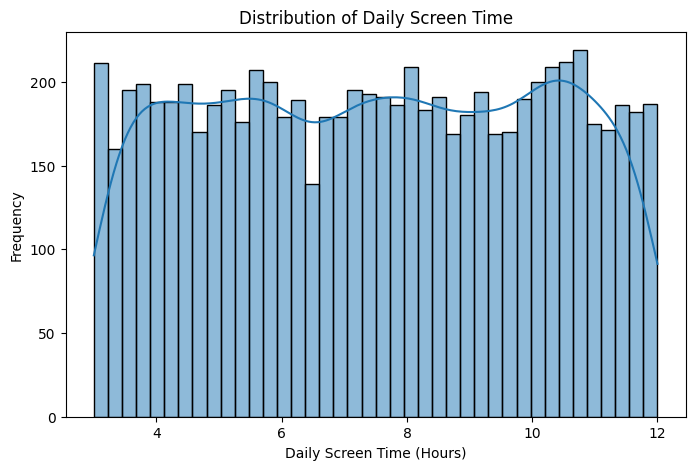

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data['daily_screen_time_hours'], bins=40, kde=True)
plt.title('Distribution of Daily Screen Time')
plt.xlabel('Daily Screen Time (Hours)')
plt.ylabel('Frequency')
plt.show()

### Most users spend between 5–9 hours daily on smartphones, with a few users showing extremely high screen time behavior.

## Finding extreme users

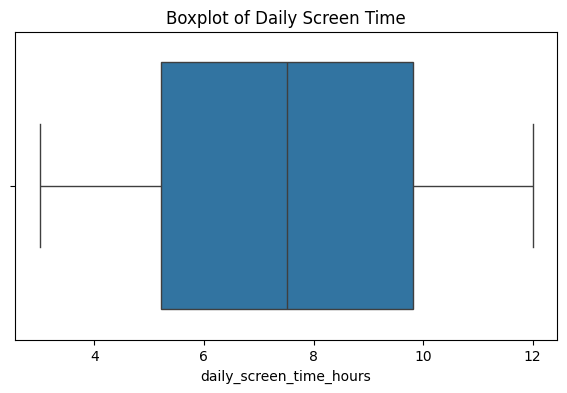

In [11]:
plt.figure(figsize=(7,4))
sns.boxplot(x=data['daily_screen_time_hours'])
plt.title('Boxplot of Daily Screen Time')
plt.show()

### Several outliers are visible, indicating that some users spend unusually high amounts of time on smartphones.

# Analyze sleep_hours

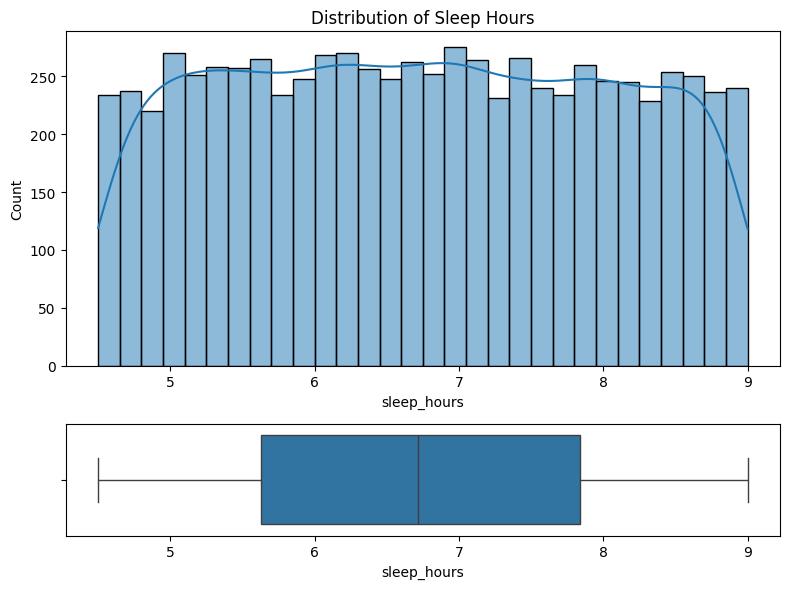

In [12]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 6),
    gridspec_kw={'height_ratios': [3, 1]}
)

sns.histplot(data['sleep_hours'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sleep Hours')

sns.boxplot(x=data['sleep_hours'], ax=axes[1])

plt.tight_layout()
plt.show()

### Most users sleep between 5–8 hours, while some users show lower sleep duration patterns.

# Analyze notifications_per_day

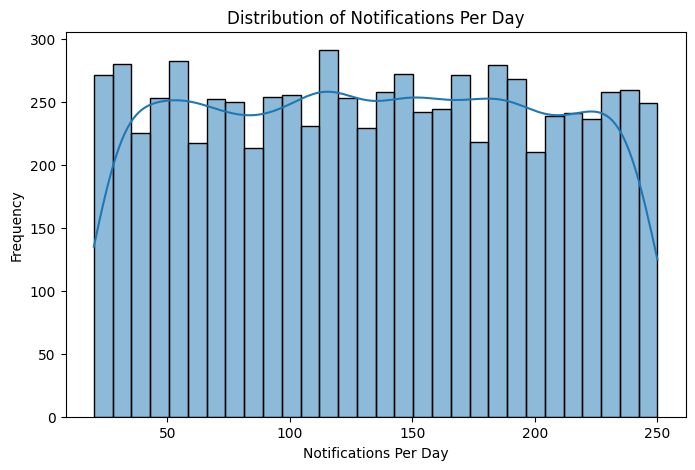

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(data['notifications_per_day'], bins=30, kde=True)

plt.title('Distribution of Notifications Per Day')
plt.xlabel('Notifications Per Day')
plt.ylabel('Frequency')

plt.show()

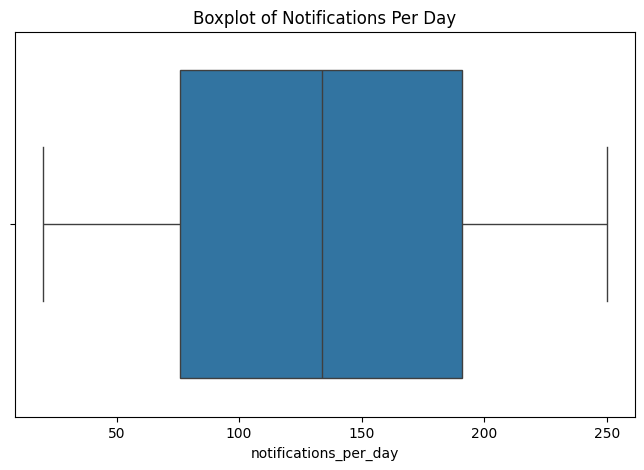

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['notifications_per_day'])
plt.title('Boxplot of Notifications Per Day')
plt.show()

# Compare With Addiction

### Screen Time vs Addiction

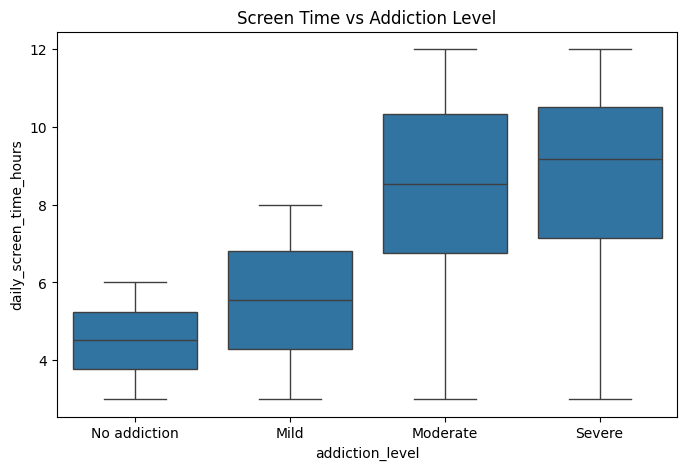

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='addiction_level',
    y='daily_screen_time_hours',
    data=data
)
plt.title('Screen Time vs Addiction Level')

plt.show()

### Users with severe addiction levels generally spend more time on smartphones compared to non-addicted users.

# Sleep vs Addiction

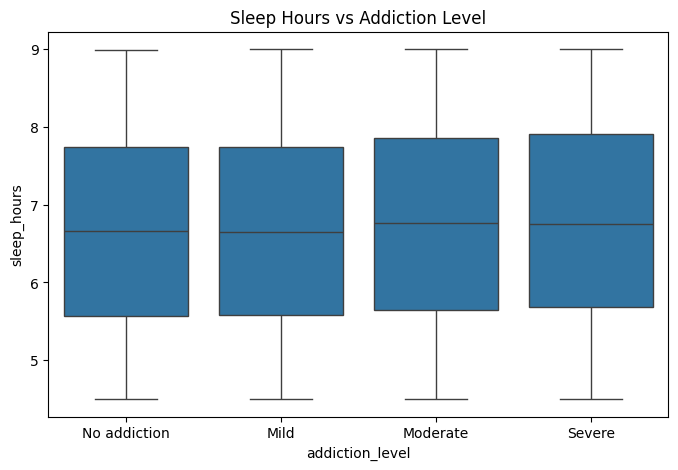

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='addiction_level',
    y='sleep_hours',
    data=data
)
plt.title('Sleep Hours vs Addiction Level')
plt.show()

# Notifications vs Addiction

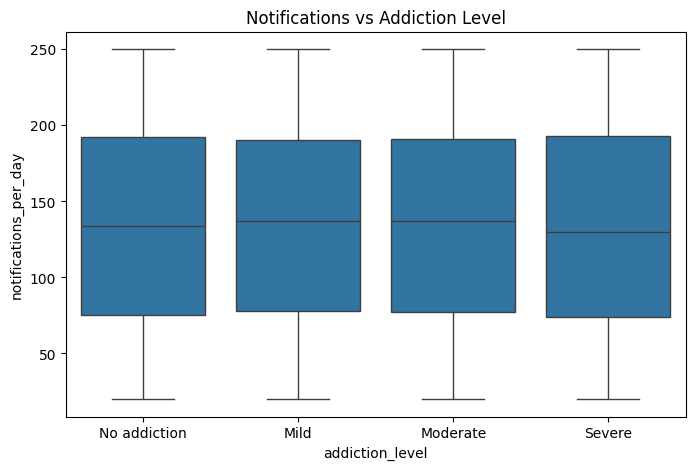

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='addiction_level',
    y='notifications_per_day',
    data=data
)
plt.title('Notifications vs Addiction Level')
plt.show()